see eg. dev28 for how to pick rois

In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [2]:
# ========== TRANSECT 057 (DEFAULT) ==========
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file from transect 057
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
Spectral bands: 210
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📊 Spectral configuration:
   Wavelength range: 380.9 -

In [ ]:
# ===== DEMONSTRATING FRAME RATE CALCULATION =====
import h5py
import numpy as np

# Get the H5 file path
h5_file = cube.folder / f"{cube.file_boundaries[0]['file']}.h5"
print(f"📂 H5 file: {h5_file.name}\n")

with h5py.File(h5_file, "r") as f:
    # Read timestamps for each line-scan (track)
    timestamps = f["processed/radiance/timestamp"][:]

    print(f"📊 Timestamp data:")
    print(f"   Total tracks (line-scans): {len(timestamps)}")
    print(f"   First timestamp: {timestamps[0]:.3f} seconds (unix epoch)")
    print(f"   Last timestamp: {timestamps[-1]:.3f} seconds")
    print(f"   Total duration: {timestamps[-1] - timestamps[0]:.2f} seconds")

    # Calculate time difference between consecutive frames FOR ALL TRACKS
    time_diffs = np.diff(timestamps)  # This gives us (n-1) intervals for n tracks

    print(f"\n⏱️  Frame timing (checked ALL {len(time_diffs)} intervals):")
    print(f"   Mean time between frames: {np.mean(time_diffs):.4f} seconds")
    print(f"   Median time between frames: {np.median(time_diffs):.4f} seconds")
    print(f"   Std dev: {np.std(time_diffs):.4f} seconds")
    print(f"   Min time between frames: {np.min(time_diffs):.4f} seconds")
    print(f"   Max time between frames: {np.max(time_diffs):.4f} seconds")

    # Remove any invalid differences (should be none, but just in case)
    valid_diffs = time_diffs[time_diffs > 0]
    print(f"   Valid intervals: {len(valid_diffs)} / {len(time_diffs)}")

    # Calculate frame rate from all valid intervals
    avg_time_diff = np.mean(valid_diffs)
    frame_rate = 1.0 / avg_time_diff

    # Calculate frame rate distribution (what frequencies do we actually get?)
    frame_rates = 1.0 / valid_diffs

    print(f"\n🎯 Frame rate statistics (from ALL intervals):")
    print(f"   Mean frame rate: {np.mean(frame_rates):.2f} Hz")
    print(f"   Median frame rate: {np.median(frame_rates):.2f} Hz")
    print(f"   Std dev: {np.std(frame_rates):.2f} Hz")
    print(f"   Min frame rate: {np.min(frame_rates):.2f} Hz")
    print(f"   Max frame rate: {np.max(frame_rates):.2f} Hz")
    print(f"\n   --> Checked {len(time_diffs)} consecutive track pairs")
    print(f"   --> Each track pair gives one frame rate measurement")

In [ ]:
# ===== VISUALIZE: FRAME RATE DISTRIBUTION =====
import matplotlib.pyplot as plt

with h5py.File(h5_file, "r") as f:
    timestamps = f["processed/radiance/timestamp"][:]

# Convert to relative time (seconds from start)
relative_time = timestamps - timestamps[0]
track_numbers = np.arange(len(timestamps))

# Calculate frame rates for ALL consecutive track pairs
time_diffs = np.diff(timestamps)
frame_rates = 1.0 / time_diffs

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: Track number vs time (shows linear relationship = constant frame rate)
ax1.plot(relative_time, track_numbers, "b-", linewidth=0.5)
ax1.set_xlabel("Time (seconds from start)", fontsize=11)
ax1.set_ylabel("Track Number (line-scan index)", fontsize=11)
ax1.set_title(
    "Track Number vs Time\n(Linear = constant frame rate)",
    fontsize=12,
    fontweight="bold",
)
ax1.grid(True, alpha=0.3)

# Add annotation showing the slope (frame rate)
slope = len(timestamps) / (relative_time[-1] - relative_time[0])
ax1.text(
    0.05,
    0.95,
    f"Slope = {slope:.2f} tracks/second\n= Frame rate",
    transform=ax1.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

# Plot 2: Frame rate for each consecutive track pair
ax2.plot(track_numbers[1:], frame_rates, "g-", linewidth=0.5, alpha=0.7)
ax2.axhline(
    y=np.mean(frame_rates),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(frame_rates):.2f} Hz",
)
ax2.axhline(
    y=np.median(frame_rates),
    color="orange",
    linestyle=":",
    linewidth=2,
    label=f"Median = {np.median(frame_rates):.2f} Hz",
)
ax2.set_xlabel("Track Number", fontsize=11)
ax2.set_ylabel("Instantaneous Frame Rate (Hz)", fontsize=11)
ax2.set_title(
    f"Frame Rate per Interval\n(All {len(frame_rates)} consecutive pairs)",
    fontsize=12,
    fontweight="bold",
)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)
ax2.set_ylim([18, 22])

# Plot 3: Histogram of frame rates
ax3.hist(frame_rates, bins=50, color="purple", alpha=0.7, edgecolor="black")
ax3.axvline(
    x=np.mean(frame_rates),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(frame_rates):.2f} Hz",
)
ax3.axvline(
    x=np.median(frame_rates),
    color="orange",
    linestyle=":",
    linewidth=2,
    label=f"Median = {np.median(frame_rates):.2f} Hz",
)
ax3.set_xlabel("Frame Rate (Hz)", fontsize=11)
ax3.set_ylabel("Count (number of intervals)", fontsize=11)
ax3.set_title(
    f"Frame Rate Distribution\n(n={len(frame_rates)} intervals)",
    fontsize=12,
    fontweight="bold",
)
ax3.grid(True, alpha=0.3, axis="y")
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n✅ Plot 1: Linear relationship confirms constant frame rate")
print(f"✅ Plot 2: Shows frame rate for EVERY consecutive track pair")
print(
    f"✅ Plot 3: Histogram shows frequency distribution of all {len(frame_rates)} measurements"
)
print(
    f"\n📊 Frame rate range: {np.min(frame_rates):.2f} - {np.max(frame_rates):.2f} Hz"
)
print(
    f"📊 Most common range: {np.percentile(frame_rates, 25):.2f} - {np.percentile(frame_rates, 75):.2f} Hz (25th-75th percentile)"
)

In [ ]:
# ===== DEMONSTRATING FOV CALCULATION =====
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(h5_file, "r") as f:
    # Read FOV calibration data - one angle per spatial pixel
    fov = f["processed/radiance/calibration/geometric/fieldOfView"][:]

    print(f"📐 Field of View (FOV) data:")
    print(f"   Number of spatial pixels (slits): {len(fov)}")
    print(f"   First pixel angle: {fov[0]:.2f}°")
    print(f"   Last pixel angle: {fov[-1]:.2f}°")
    print(f"   Total FOV: {fov[-1] - fov[0]:.2f}°")
    print(f"   FOV half-angle: ±{(fov[-1] - fov[0])/2:.2f}°")

    # Calculate angular sampling (degrees per pixel)
    angular_sampling = (fov[-1] - fov[0]) / (len(fov) - 1)
    print(f"\n   Angular sampling: {angular_sampling:.4f}°/pixel")
    print(f"   This means each pixel sees {angular_sampling:.4f}° of the scene")

# Visualize the FOV array
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: FOV angle for each pixel
pixel_indices = np.arange(len(fov))
ax1.plot(pixel_indices, fov, "b-", linewidth=1)
ax1.axhline(
    y=0, color="red", linestyle="--", linewidth=1, alpha=0.5, label="Center (nadir)"
)
ax1.axhline(
    y=fov[0],
    color="green",
    linestyle=":",
    linewidth=1,
    label=f"Left edge = {fov[0]:.2f}°",
)
ax1.axhline(
    y=fov[-1],
    color="green",
    linestyle=":",
    linewidth=1,
    label=f"Right edge = {fov[-1]:.2f}°",
)
ax1.set_xlabel("Pixel Index (slit number)", fontsize=11)
ax1.set_ylabel("Viewing Angle (degrees)", fontsize=11)
ax1.set_title(
    f"Field of View Calibration\n(Total FOV = {fov[-1] - fov[0]:.2f}°)",
    fontsize=12,
    fontweight="bold",
)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# Plot 2: Histogram of FOV angles
ax2.hist(fov, bins=50, color="purple", alpha=0.7, edgecolor="black")
ax2.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Center (nadir)")
ax2.set_xlabel("Viewing Angle (degrees)", fontsize=11)
ax2.set_ylabel("Count (number of pixels)", fontsize=11)
ax2.set_title(
    "Distribution of Viewing Angles\n(Uniform = linear FOV)",
    fontsize=12,
    fontweight="bold",
)
ax2.grid(True, alpha=0.3, axis="y")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n✅ The FOV is read from the H5 file calibration data")
print(f"✅ Each of the {len(fov)} spatial pixels has its own viewing angle")
print(
    f"✅ Total FOV = angle of last pixel - angle of first pixel = {fov[-1]:.2f}° - ({fov[0]:.2f}°) = {fov[-1] - fov[0]:.2f}°"
)

In [3]:
cube.list_saved_corrections()


📋 Cached illumination corrections:

📁 File: rad_uhi_20241029_115057_5
   ✓ window=unknown
     Dataset: dataCube_corrected_smoothed_gaussian_sig5p0
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=1000
     Dataset: dataCube_corrected_w1000
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=500
     Dataset: dataCube_corrected_w500
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=750
     Dataset: dataCube_corrected_w750
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ⚠️  LEGACY FORMAT (use cube.rename_legacy_corrections() to migrate):
      window=1000, strength=1.0
      Dataset: dataCube_illum_corrected_w1000_s1p00
      Shape: (2462, 968, 210), Size: 1909.2 MB

💡 Tip: Run cube.rename_legacy_corrections() to convert old format to new format


In [ ]:
# cube.rename_legacy_corrections()  # Will ask for confirmation

In [3]:
cube.apply_illumination_correction_v3(window_size=500, force_recompute=False)

🔄 Using V3 algorithm (rolling window only, strategy=memory)
✅ All files already have illumination correction (window=500, strength=1.0)
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [4]:
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)

✅ UHI alignment adjusted:
   dx (East):  -0.050 m
   dy (North): -3.000 m

💡 This will be applied in plot_georef() with coordinate_system='NED'


In [5]:
# Import ROIs from file
# cube.import_rois("rois/057_5_combined.json")
cube.import_rois("rois/057_5_many_classes.json")

📂 Imported 18 ROIs from rois/057_5_many_classes.json


In [6]:
# List all ROIs
cube.list_rois()


📂 ROI Collection (18 ROIs):
 1. 'yellow leaf': 19 pixels
     Slit range:  756 - 779
     Track range: 2100 - 2103
 2. 'brown leaf': 33 pixels
     Slit range:  756 - 782
     Track range: 1770 - 1776
 3. 'dark1': 98 pixels
     Slit range:  606 - 740
     Track range: 729 - 765
 4. 'dark2': 140 pixels
     Slit range:  174 - 356
     Track range: 1094 - 1148
 5. 'sediment': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 6. 'single bomb ring': 61 pixels
     Slit range:  224 - 306
     Track range: 1124 - 1137
 7. 'single bomb inside': 82 pixels
     Slit range:  244 - 291
     Track range: 1126 - 1135
 8. 'double bomb 1': 114 pixels
     Slit range:  809 - 880
     Track range: 1500 - 1516
 9. 'double bomb 2': 61 pixels
     Slit range:  659 - 690
     Track range: 1540 - 1547
10. 'triple bomb 1': 71 pixels
     Slit range:  662 - 701
     Track range: 593 - 598
11. 'triple bomb 2': 42 pixels
     Slit range:  639 - 654
     Track range: 700 - 705
12. 'triple bo

In [ ]:
# cube.rename_roi("tripple bomb 1", "triple bomb 1")
# cube.rename_roi("tripple bomb 2", "triple bomb 2")
# cube.rename_roi("tripple bomb 3", "triple bomb 3")

In [ ]:
cube.export_rois("./ROIs/057_5_many_classes.json")

In [ ]:
# %matplotlib qt
# cube.plot_interactive_rgb(
#     roi_name="single bomb ring", use_corrected=True, marker_size=2
# )

In [6]:
roi_totals = [
    "sediment",
    "dark spots",
    "all bombs",
]

roi_names = [
    "single bomb ring",
    "single bomb inside",
    "double bomb 1",
    "double bomb 2",
    "triple bomb 1",
    "triple bomb 2",
    "triple bomb 3",
    "dark area near bomb",
    "isolated dark area",
    "sediment",
]

In [ ]:
%matplotlib inline

In [7]:
# Create output directory for saving figures
output_dir_057 = Path.cwd().parent / "images_for_publication" / "057_roi_spectras"
output_dir_057.mkdir(parents=True, exist_ok=True)

print(f"📁 Output directory: {output_dir_057}")
print(f"✅ Ready to save figures")

📁 Output directory: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\057_roi_spectras
✅ Ready to save figures


🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates


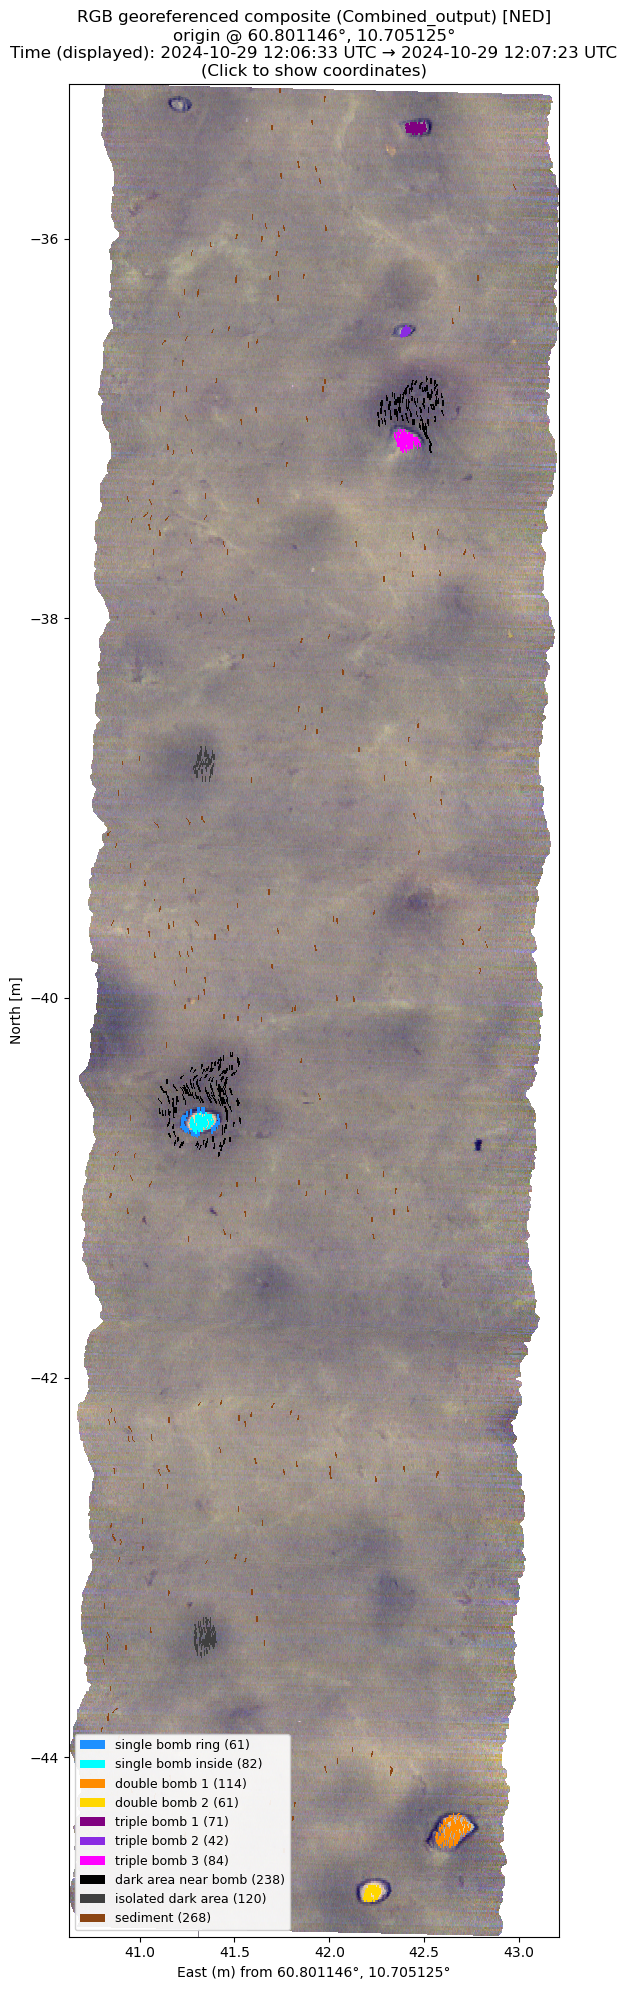

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates


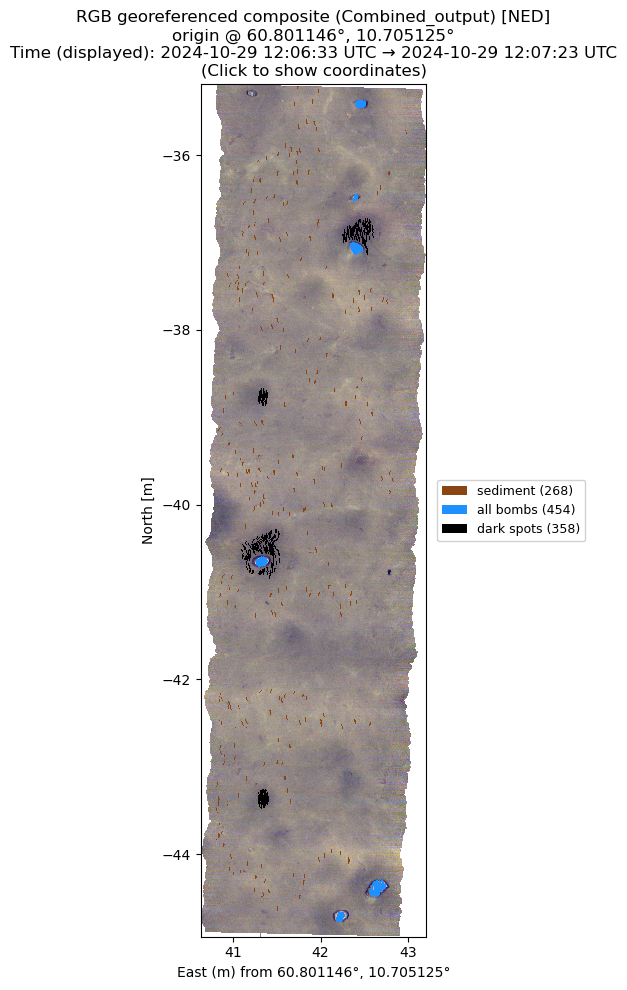

In [9]:
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
    roi_collection=roi_names,
    roi_legend_loc="lower left",  # Changed from "outside" to "lower left"
    roi_solid_pixel_size=3,
    roi_overlay_mode="solid",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(30, 10),
    roi_collection=roi_totals,
    # roi_legend_loc="lower left",  # Changed from "outside" to "lower left"
    roi_legend_loc="outside",  # Changed from "outside" to "lower left"
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
    roi_overlay_mode="solid",
    roi_solid_pixel_size=5,
)

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates


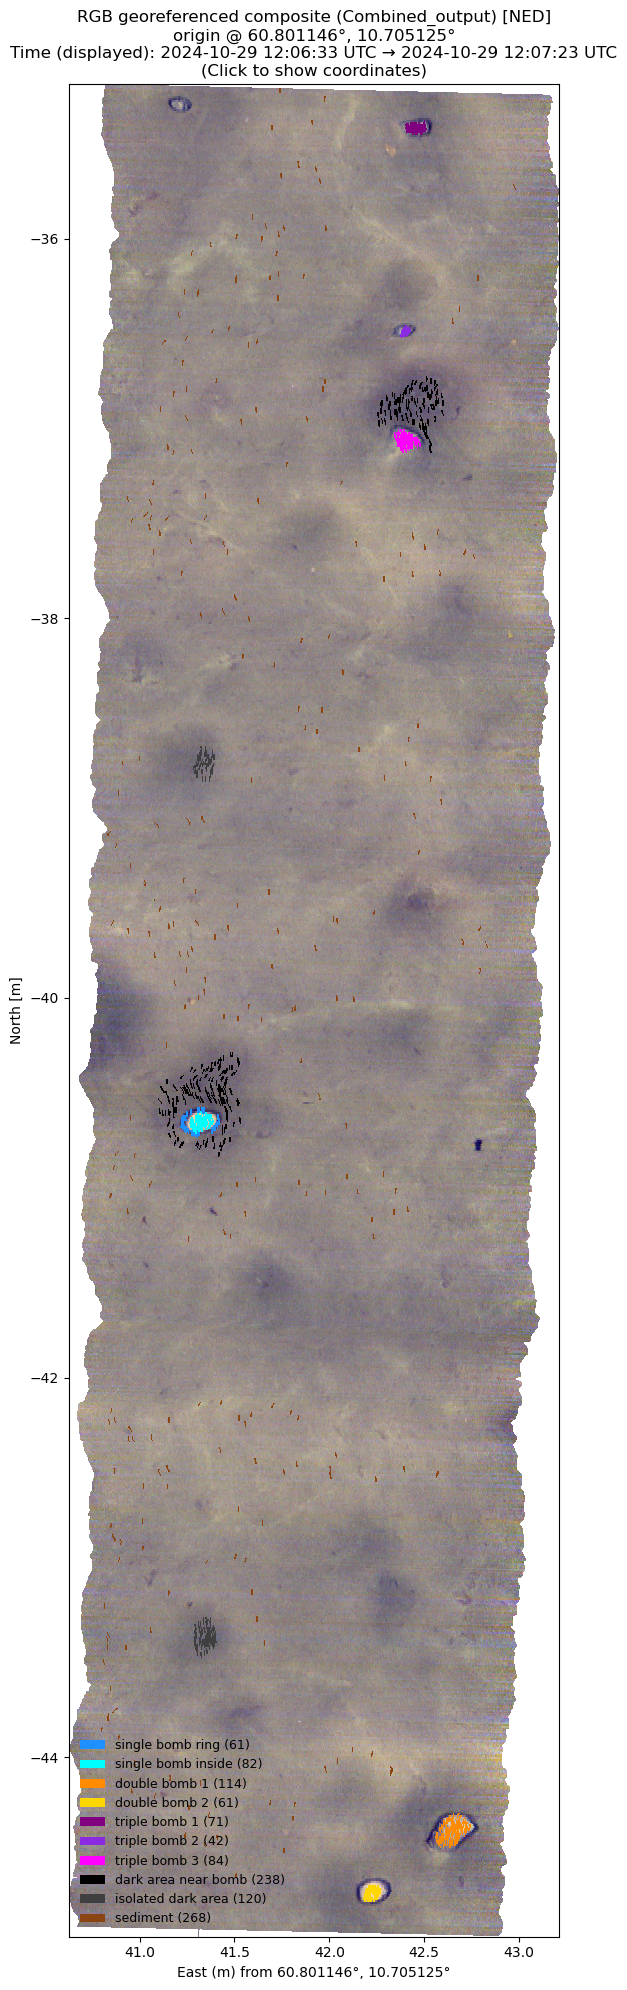

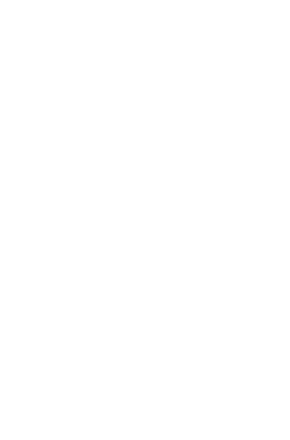

In [10]:
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
    roi_collection=roi_names,
    roi_legend_loc="lower left",
    roi_solid_pixel_size=3,
    roi_overlay_mode="solid",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
    roi_legend_frameon=False,  # NEW: No border for clean look
    save_file=str(output_dir_057 / "057_mosaic_rois.pdf"),
    save_dpi=300,
    display_legend_only=True,  # NEW: Display legend in separate clean window
)

# cube.plot_georef(
#     apply_alignment_shift=True,
#     use_corrected=True,
#     coordinate_system="NED",
#     track_start=config.UHI_TRACK_RANGE[0],
#     track_end=config.UHI_TRACK_RANGE[1],
#     figsize=(30, 10),
#     roi_collection=roi_totals,
#     # roi_legend_loc="lower left",  # Changed from "outside" to "lower left"
#     roi_legend_loc="outside",  # Changed from "outside" to "lower left"
#     roi_marker_edgewidth=0,
#     roi_legend_markersize=50,
#     roi_overlay_mode="solid",
#     roi_solid_pixel_size=5,
#     save_file=str(output_dir_057 / "roi_georef_totals.pdf"),
#     save_dpi=300,
# )

# print(f"✅ Saved: roi_georef_detailed.pdf")
# print(f"✅ Saved: roi_georef_totals.pdf")

# Test New Legend Features

The updated `plot_georef` function now supports:

1. **Legend frame control**: 
   - `roi_legend_frameon=True/False` - Show/hide legend border
   - `roi_legend_facecolor='white'` - Legend background color
   - `roi_legend_framealpha=0.9` - Legend transparency

2. **Clean mosaic display**:
   - `display_only_mosaic=True` - Remove axes/labels/ticks/borders (keep mosaic + legend only)
   
3. **Separate legend display**:
   - `display_legend_only=True` - Create a separate figure with ONLY the legend

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates


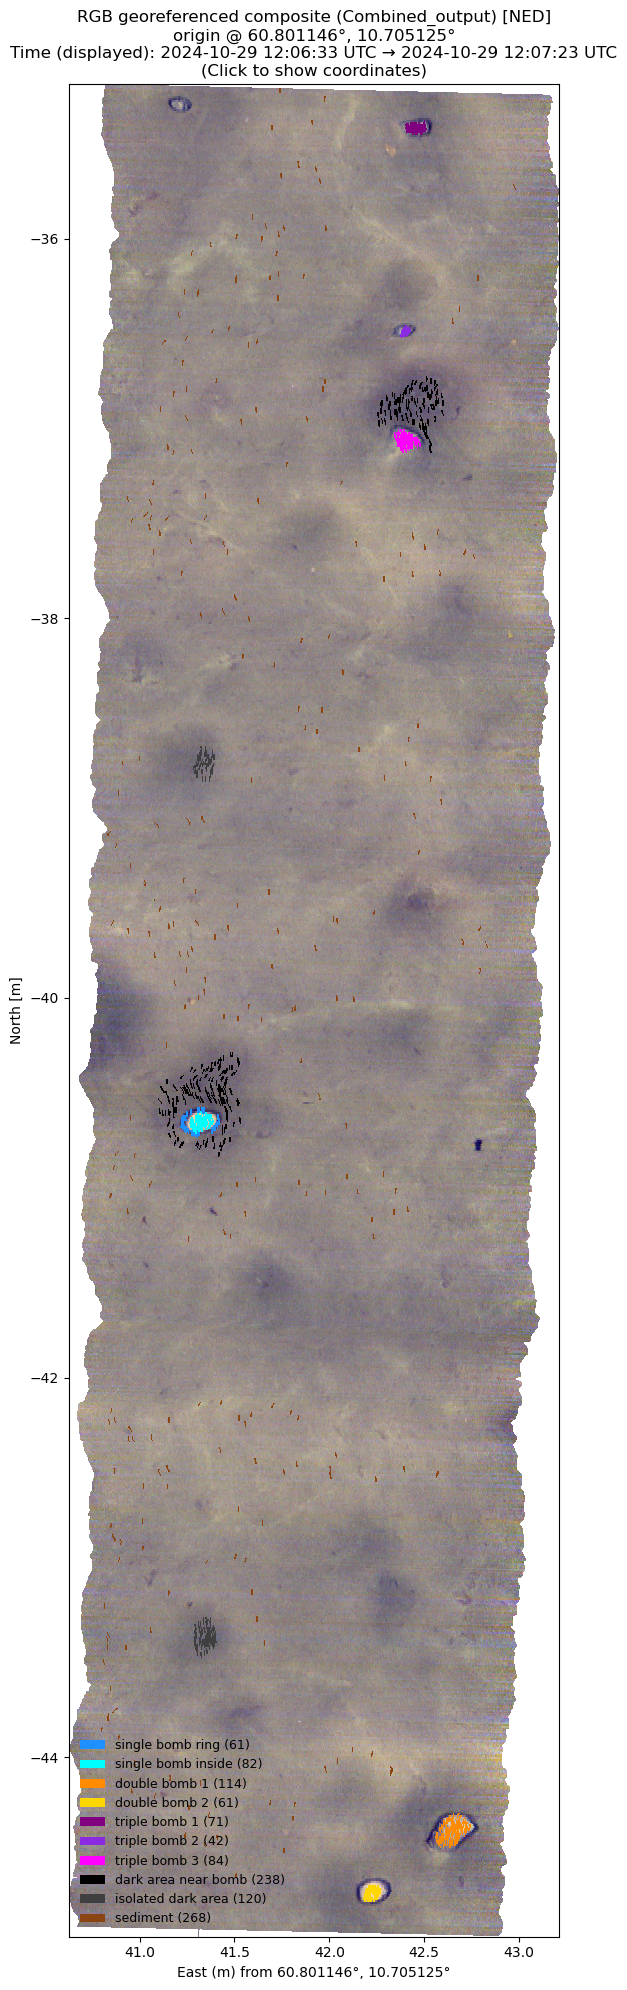

In [ ]:
# Test 1: Plot with NO legend frame (clean look)
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
    roi_collection=roi_names,
    roi_legend_loc="lower left",
    roi_solid_pixel_size=3,
    roi_overlay_mode="solid",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
    # NEW PARAMETERS - No frame, solid white background
    roi_legend_frameon=False,  # No border!
    roi_legend_facecolor="white",
    roi_legend_framealpha=1.0,  # Solid background
)

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates


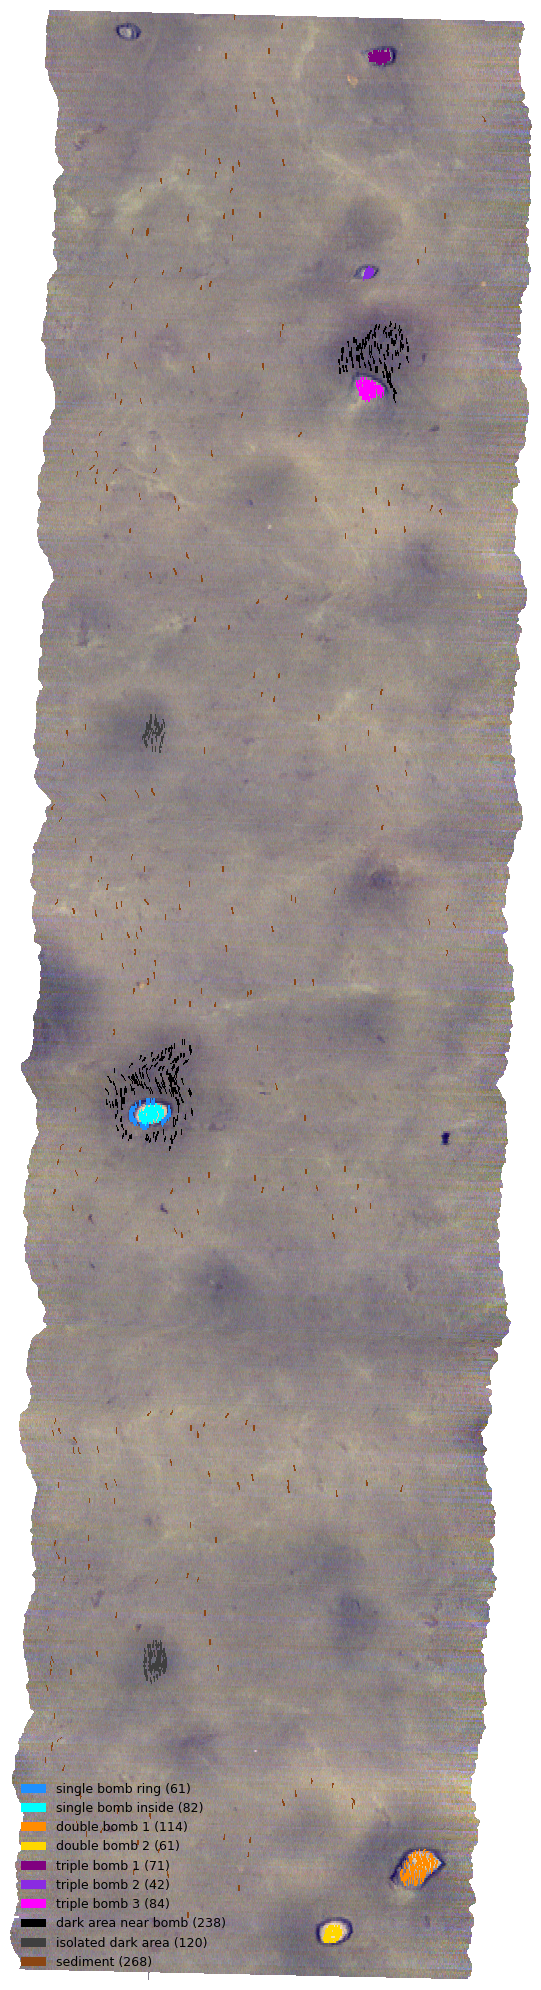

In [8]:
# Test 2: Clean mosaic - no axes/labels/ticks/borders (keep mosaic + legend)
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
    roi_collection=roi_names,
    roi_legend_loc="lower left",
    roi_solid_pixel_size=3,
    roi_overlay_mode="solid",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
    roi_legend_frameon=False,
    # Save main plot
    save_file=str(output_dir_057 / "057_mosaic_rois.pdf"),
    save_dpi=300,
    # NEW: Display clean mosaic only (no axes/borders, keep legend)
    display_only_mosaic=True,
)

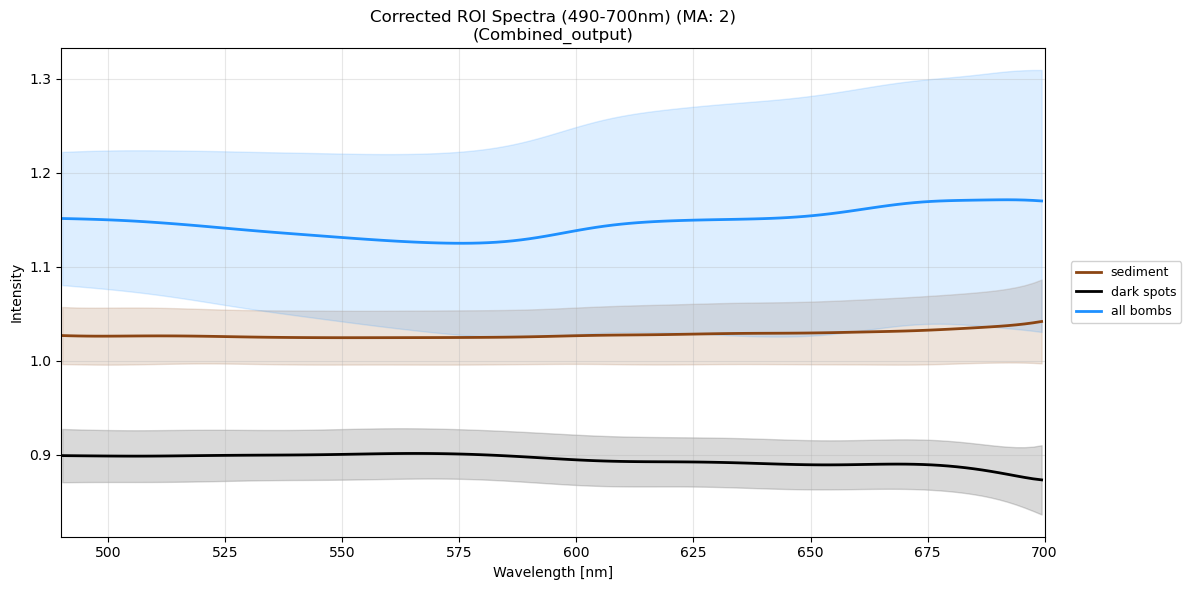

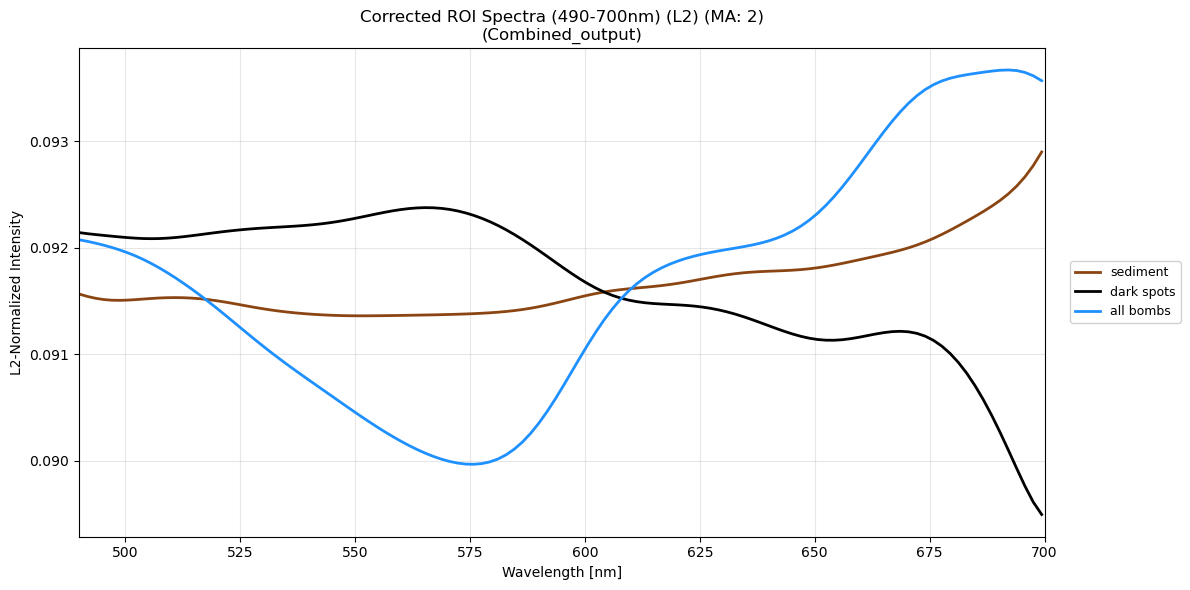

In [9]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    show_std=True,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
)

# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
)

✅ Saved spectrum plot: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\057_roi_spectras\057_spectrum_rad.pdf


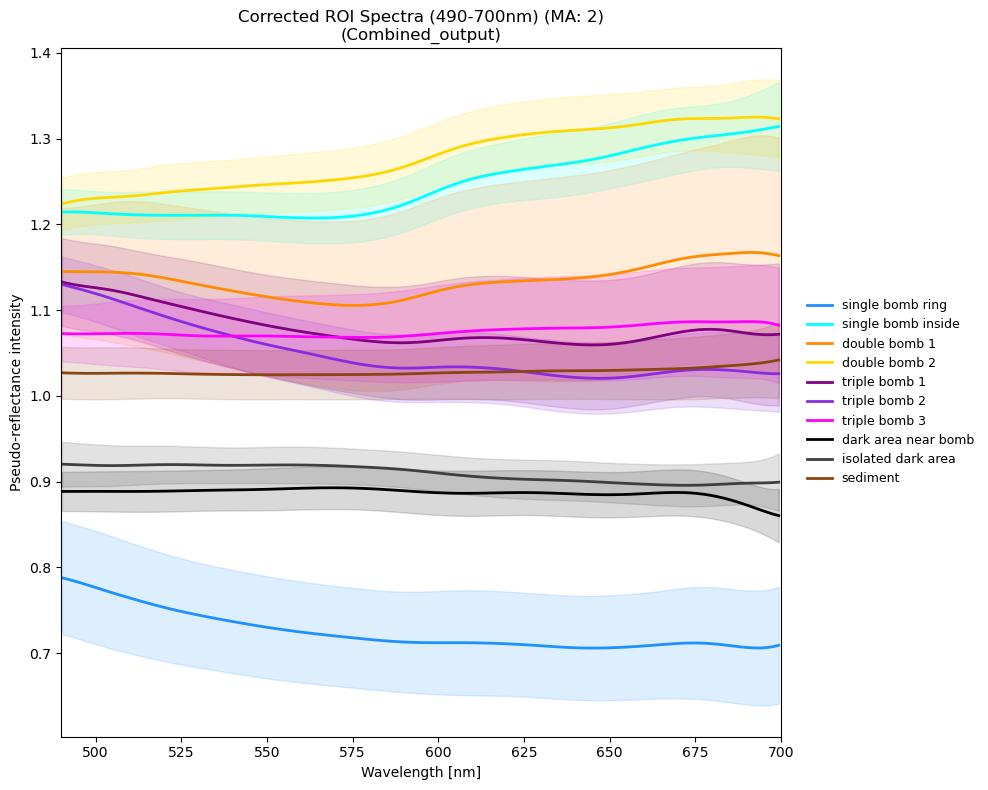

✅ Saved spectrum plot: e:\mjosa_complete\gref4hsi\mjosa_code\images_for_publication\057_roi_spectras\057_spectrum_normalized.pdf


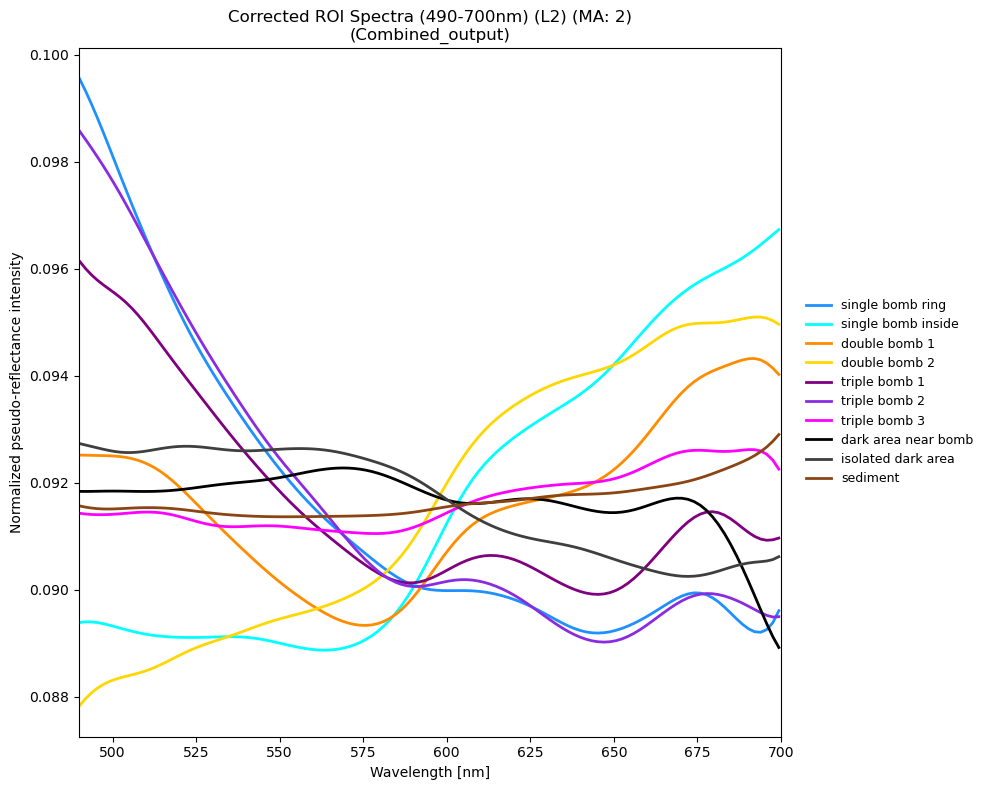

In [9]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    show_std=True,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Pseudo-reflectance intensity",  # Custom y-axis label
    show_grid=False,  # NEW: Remove grid lines
    legend_frameon=False,  # NEW: Remove legend border
    save_file=str(output_dir_057 / "057_spectrum_rad.pdf"),  # NEW: Save as PDF
    save_dpi=300,
)

cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Normalized pseudo-reflectance intensity",  # Custom y-axis label
    show_grid=False,  # NEW: Remove grid lines
    legend_frameon=False,  # NEW: Remove legend border
    save_file=str(output_dir_057 / "057_spectrum_normalized.pdf"),  # NEW: Save as PDF
    save_dpi=300,
)

# test different nornalziation

In [ ]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    # normalize_method=None,  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    normalize_method="mean",  # Already normalized in memory
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Pseudo-reflectance intensity",  # Custom y-axis label
)
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    # normalize_method=None,  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    normalize_method="mean_center",  # Already normalized in memory
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Pseudo-reflectance intensity",  # Custom y-axis label
)
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    # normalize_method=None,  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    normalize_method="snv",  # Already normalized in memory
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Pseudo-reflectance intensity",  # Custom y-axis label
)
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    # normalize_method=None,  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    normalize_method="minmax",  # Already normalized in memory
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Pseudo-reflectance intensity",  # Custom y-axis label
)
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    # normalize_method=None,  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    normalize_method="msc",  # Already normalized in memory
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Pseudo-reflectance intensity",  # Custom y-axis label
)

In [ ]:
# Visualize filtered training ROIs
%matplotlib qt
cube.plot_georef(
    use_corrected=True,
    figsize=(40, 10),
)

---

# 📖 Methods Documentation

This notebook demonstrates the complete workflow for ROI-based spectral analysis of underwater hyperspectral imagery.

---

## 1. UHI Camera Specifications

### Hardware Configuration
- **Sensor**: UHI-4 pushbroom line-scan hyperspectral imager
- **Full spatial resolution**: 1936 pixels (across-track, pre-binning)
- **Spatial binning**: 2× (1936 ÷ 968 = 2× binning)
- **Active slits**: 968 spatial pixels (after binning)
- **Spectral bands**: 210 wavelength channels
- **Wavelength range**: **380.9 - 748.6 nm** (visible to near-infrared)
- **Band spacing**: ~1.75 nm (center-to-center distance between adjacent bands)
- **Spectral resolution (FWHM)**: ~5.5 nm (manufacturer specification)

#### Understanding Spectral Sampling

**Band spacing** and **spectral resolution** are two different concepts:

**Band Spacing (1.75 nm)**:
- Distance between the center wavelengths of adjacent bands
- Calculated: `(748.6 - 380.9) / 210 = 1.75 nm`
- Read from: `processed/radiance/calibration/spectral/band2Wavelength` in H5 files
- Tells you how densely the spectrum is sampled

**Spectral Resolution / FWHM (5.5 nm)**:
- Full Width at Half Maximum of each band's spectral response curve
- From manufacturer specification (not stored in H5 files)
- Tells you how "wide" each band is (how much of the spectrum it sees)

**Key insight**: Since FWHM (5.5 nm) > band spacing (1.75 nm), the spectral bands **overlap**. This is intentional and common in hyperspectral sensors - it provides smoother spectral curves and better coverage with no gaps.

### Optical Configuration
- **Field of View (FOV)**: **50.62°** total (±25.31° from center)
- **Angular range**: -25.32° to +25.30° (across-track)
- **Angular sampling**: 0.0523°/pixel (968 pixels)
- **Focal length equivalent**: ~930 pixels (from FOV calibration)

#### How FOV is Calculated

The Field of View is extracted from the H5 file calibration data:

```python
# Read FOV angles for each pixel from H5 file
fov = h5_file['processed/radiance/calibration/geometric/fieldOfView'][:]
# Calculate total FOV from first to last pixel
total_fov = fov[-1] - fov[0]  # Result: 50.62°
```

The FOV array contains the viewing angle for each of the 968 spatial pixels. The total FOV is the angular span from the leftmost to rightmost pixel.

### Acquisition Performance
- **Frame rate**: ~20 Hz (50 ms/frame average)
- **Frame rate range**: 18.8 - 21.4 Hz (variable depending on exposure)
- **Line scan speed**: 19.96 lines/second
- **Exposure time**: ~50 ms/frame (fixed exposure)
- **Total mission time**: 123.3 seconds (file 5)
- **Total frames acquired**: 2462 line-scans (file 5)

#### How Frame Rate is Calculated

The frame rate is derived from timestamp differences in the H5 file:

```python
# Read unix timestamps for each frame
timestamps = h5_file['processed/radiance/timestamp'][:]
# Calculate time differences between consecutive frames
time_diffs = np.diff(timestamps)
# Remove any zero or negative differences (rare errors)
valid_diffs = time_diffs[time_diffs > 0]
# Calculate average time between frames
avg_time_diff = np.mean(valid_diffs)  # Result: ~0.0501 seconds
# Convert to frame rate
frame_rate = 1.0 / avg_time_diff  # Result: ~20.0 Hz
```

The timestamp array contains the unix epoch time for each line-scan acquisition, allowing precise frame rate calculation.

### Data Cube Structure
Hyperspectral data organized as **(T × S × B)**:
- **T** (Tracks): Line-scans along vehicle trajectory (varies per file)
- **S** (Slits): 968 pixels across-track (perpendicular to motion)
- **B** (Bands): 210 spectral channels

**Example file `rad_uhi_20241029_115057_5`**:
- Shape: `(2462, 968, 210)`
- 2462 line-scans × 968 pixels × 210 wavelengths
- ~501 million spectral measurements total

### Spatial Binning Rationale
**2× binning** provides:
- ✅ Higher signal-to-noise ratio (4× more photons per pixel)
- ✅ Faster frame rate (2× speed increase)
- ✅ Smaller file sizes (2× reduction)

Trade-off:
- ❌ Lower spatial resolution (2× coarser detail)

For underwater imaging, SNR gain outweighs resolution loss.

---

## 2. ROI Selection Workflow

### Interactive Selection Tool
ROIs selected using Qt matplotlib interactive window:

```python
%matplotlib qt
cube.plot_interactive_rgb(
    roi_name="single bomb ring",
    use_corrected=True,
    marker_size=2
)
```

**Controls**:
- **Left click**: Add pixel to ROI
- **Right click**: Remove pixel from ROI
- **Close window**: Save ROI to memory

**Parameters**:
- `roi_name`: ROI identifier (e.g., "sediment", "double bomb 1")
- `use_corrected=True`: Use illumination-corrected data
- `marker_size=2`: Selection marker size (2×2 pixel square)
- `red_wl=620`, `green_wl=565`, `blue_wl=490`: RGB display wavelengths
- `load_existing=True`: Continue editing existing ROI

**Output**: Selected pixels stored as `(slit_idx, track_idx)` tuples in `cube.roi_collection[roi_name]`

### ROI Persistence
**Export to JSON**:
```python
cube.export_rois("./ROIs/057_5_many_classes.json")
```

**Import from JSON**:
```python
cube.import_rois("rois/057_5_many_classes.json")
```

**List ROIs**:
```python
cube.list_rois()  # Shows ROI name → pixel count
```

JSON format preserves exact pixel coordinates for reproducibility across sessions.

---

## 3. ROI Organization

Two hierarchical levels for different analysis purposes:

### Individual Classes (`roi_names`)
10 specific ROI types for detailed analysis:
- `double bomb 1`, `double bomb 2`
- `tripple bomb 1`, `tripple bomb 2`, `tripple bomb 3`
- `single bomb ring`, `single bomb inside`
- `isolated dark area`, `dark area near bomb`
- `sediment`

**Use cases**: Fine-grained spectral comparison, spatial pattern analysis

### Grouped Classes (`roi_totals`)
3 aggregated categories for high-level classification:
- `sediment`: Background substrate
- `dark spots`: Non-bomb dark features
- `all bombs`: Combined explosive signatures

**Use cases**: Simplified visualization, binary classification

---

## 4. Georeferenced Visualization

ROIs overlaid on georeferenced RGB imagery using `cube.plot_georef()`:

### Detailed View (50×20 inch)
```python
cube.plot_georef(
    apply_alignment_shift=True,      # Apply manual alignment (dx=-0.05, dy=-3.0)
    use_corrected=True,              # Illumination-corrected data
    coordinate_system="NED",         # North-East-Down frame
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
    roi_collection=roi_names,        # Show all 10 individual classes
    roi_legend_loc="lower left",
    roi_solid_pixel_size=3,          # 3×3 meter blocks
    roi_overlay_mode="solid",        # Solid color fill
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)
```

### Grouped View (30×10 inch)
```python
cube.plot_georef(
    # ... same base settings ...
    figsize=(30, 10),
    roi_collection=roi_totals,       # Show 3 grouped categories
    roi_legend_loc="outside",
    roi_solid_pixel_size=5,          # Larger 5×5 meter blocks
)
```

### Visualization Parameters

**`roi_overlay_mode`**:
- `"solid"`: Color-filled pixel blocks (high visibility)
- `"markers"`: Point markers (scatter style)

**`roi_solid_pixel_size`**: 
- Visual size in meters (3 = 3×3 m blocks)
- Larger values improve visibility in large-scale plots

**`roi_legend_loc`**: 
- Inside: `"lower left"`, `"upper right"`, etc.
- Outside: `"outside"` (better for many classes)

**Color assignment**: Each ROI gets unique color from colormap, consistent across plots

---

## 5. Spectral Analysis

### Preprocessing Pipeline
1. **Illumination correction**: `cube.apply_illumination_correction_v2(window_size=500)`
2. **Wavelength cropping**: `[490, 700]` nm (underwater optical window)
3. **Gaussian smoothing**: `sigma=5`, `wavelength_smoothing=2`

### Spectral Plots

**Absolute intensity** (with standard deviation):
```python
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=[490, 700],
    normalize_method=None,
    show_std=True,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
)
```

**L2-normalized** (relative spectral shape):
```python
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=[490, 700],
    normalize_method="l2",
    show_std=False,  # Hide std for cleaner comparison
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
)
```

### Analysis Workflow Summary
1. **Select ROIs** → Interactive Qt tool (`plot_interactive_rgb`)
2. **Export ROIs** → JSON persistence (`export_rois`)
3. **Import ROIs** → Load in analysis notebook (`import_rois`)
4. **Organize** → Define `roi_names` and `roi_totals` lists
5. **Visualize spatially** → Georeferenced overlays (`plot_georef`)
6. **Extract spectra** → ROI-based spectral signatures (`plot_spectrum`)

---

## 6. Coordinate Systems and Alignment

### Reference Frames
- **EPSG:32632**: UTM Zone 32N (Lake Mjøsa region)
- **NED frame**: North-East-Down local coordinates (origin at `config.MJOSA_ORIGIN`)
- **Track/Slit indices**: Native hyperspectral cube coordinates

### Manual Alignment
UHI data manually aligned to MBES bathymetry:
```python
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)
```
- `dx = -0.05 m` (0.05 m west)
- `dy = -3.0 m` (3 m south)

Applied when `apply_alignment_shift=True` in `plot_georef()`.

---